In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

In [3]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

In [4]:
X = df.drop("medv", axis=1)
y = df["medv"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [7]:
model = MLPRegressor(
    hidden_layer_sizes=(50, 50),
    activation='relu',
    solver='adam',
    max_iter=1,
    warm_start=True,
    random_state=42
)

In [41]:
epochs = 100
train_loss = []
test_loss = []

for i in range(epochs):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)


    train_loss.append(mean_squared_error(y_train, y_train_pred))
    test_loss.append(mean_squared_error(y_test, y_test_pred))

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

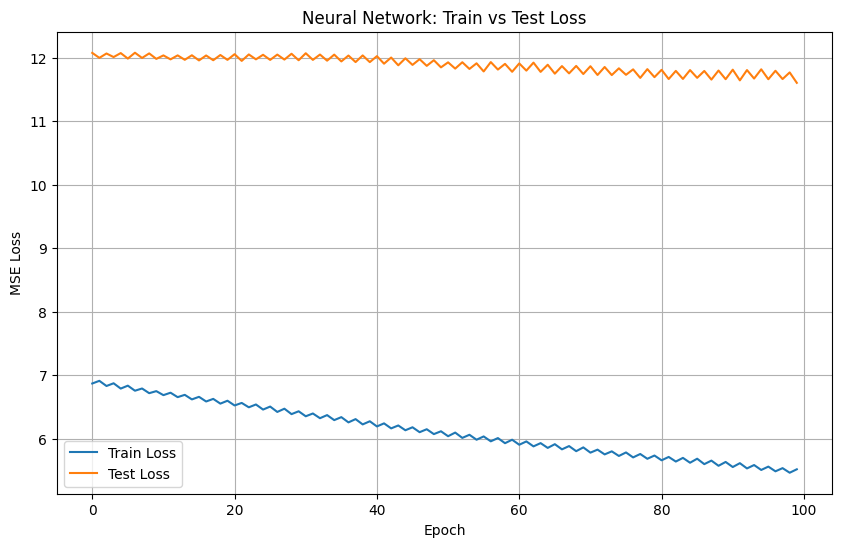

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_loss[:epochs], label="Train Loss")
plt.plot(range(epochs), test_loss[:epochs], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Neural Network: Train vs Test Loss")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
print("Final Train Score (R2):", model.score(X_train, y_train))
print("Final Test Score (R2):", model.score(X_test, y_test))

Final Train Score (R2): 0.9365031492238627
Final Test Score (R2): 0.8418020894196196


In [28]:
param_grid = {
    'hidden_layer_sizes': [(50,), (50,50), (100,)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01]
}

In [30]:
grid_model = MLPRegressor(max_iter=500, random_state=42)

grid = GridSearchCV(grid_model, param_grid, cv=3, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptro

GridSearchCV(cv=3, estimator=MLPRegressor(max_iter=500, random_state=42),
             param_grid={'activation': ['relu', 'tanh'],
                         'hidden_layer_sizes': [(50,), (50, 50), (100,)],
                         'learning_rate_init': [0.001, 0.01]},
             scoring='neg_mean_squared_error')

In [31]:
print("Best Parameters:", grid.best_params_)


Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01}


In [32]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Best Model Test MSE:", mean_squared_error(y_test, y_pred_best))
print("Best Model Test R2:", best_model.score(X_test, y_test))

Best Model Test MSE: 12.471518514137527
Best Model Test R2: 0.8299348816237643
